<a href="https://colab.research.google.com/github/akshadjaiswal005/Machine-Learning-TAE1-Group8/blob/main/Tisha_Models/Tisha_Decision_Tree_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS23059 Tisha Mondal (DECISION TREE MODEL)

# Decision Tree Model - Heart Disease Prediction

This notebook implements the Decision Tree algorithm on the UCI Heart Disease dataset.
It includes data preprocessing, feature engineering, model training, and performance evaluation
using metrics such as accuracy, confusion matrix, and classification report.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Models
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
url = "https://raw.githubusercontent.com/akshadjaiswal005/Machine-Learning-TAE1-Group8/refs/heads/main/heart_disease_uci.csv"
df = pd.read_csv(url)

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
print("\nNull Values Check:")
print(df.isnull().sum())


Null Values Check:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n", df.columns)

print("\nInfo:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (920, 16)

Columns:
 Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       92

In [6]:
# Basic Preprocessing
# Drop unnecessary column
df = df.drop("id", axis=1)

# Handle missing values
df = df.dropna()

In [7]:
before_rows = df.shape[0]
df = df.dropna()
after_rows = df.shape[0]

print("Before rows:", before_rows)
print("After rows:", after_rows)
print("Dropped rows:", before_rows - after_rows)

Before rows: 299
After rows: 299
Dropped rows: 0


In [8]:
# Convert Target Column
# Convert 'num' into binary classification
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)


Class Distribution:
num
0    160
1    139
Name: count, dtype: int64


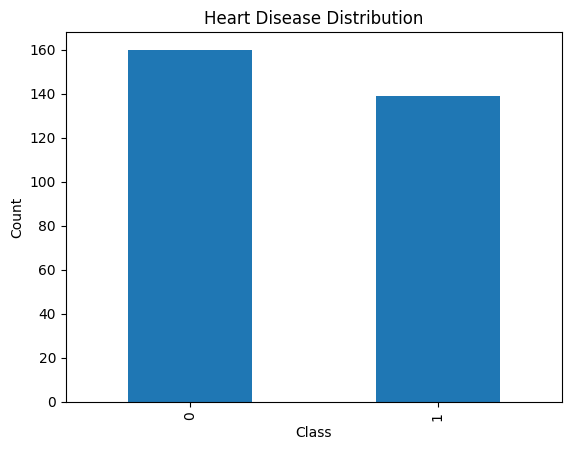

In [9]:
import matplotlib.pyplot as plt

print("\nClass Distribution:")
print(df['num'].value_counts())

df['num'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [10]:
# Encode Categorical Columns
df = pd.get_dummies(df, drop_first=True)

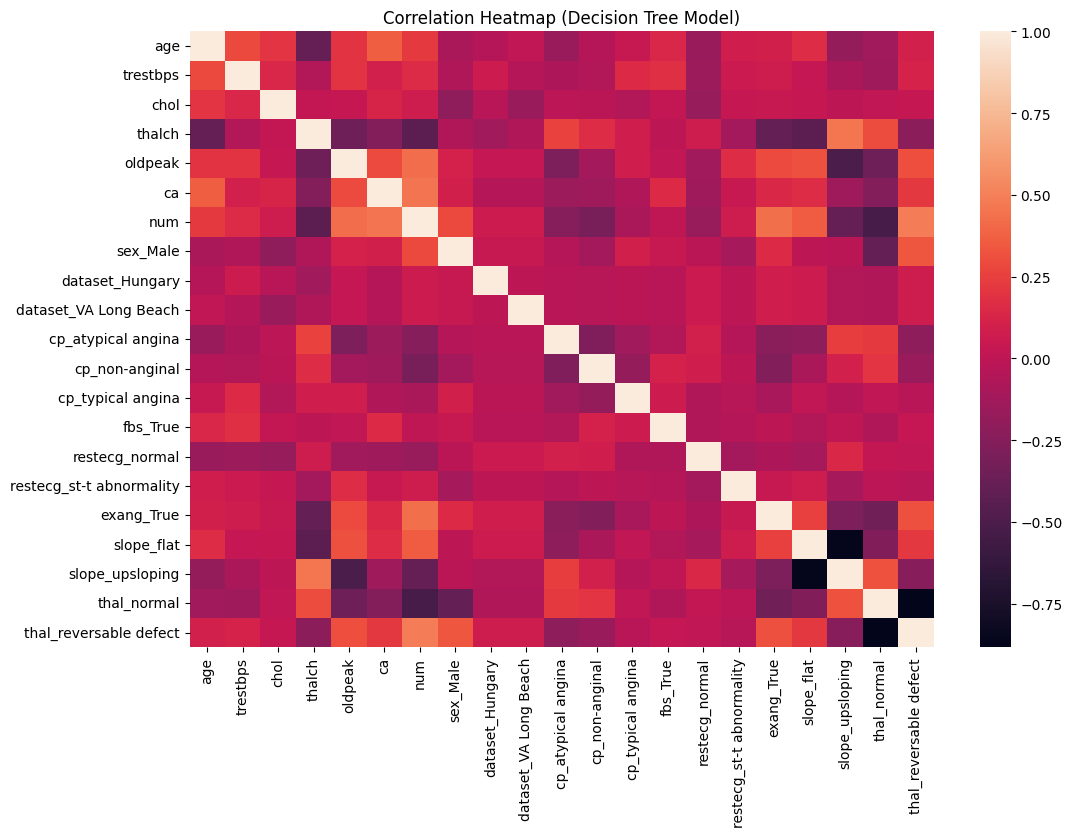

In [11]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap (Decision Tree Model)")
plt.show()

In [12]:
# Define Features & Target
X = df.drop("num", axis=1)
y = df["num"]

In [13]:
# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [14]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

PART A: DECISION TREE CLASSIFICATION

In [15]:
# Train Classifier
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

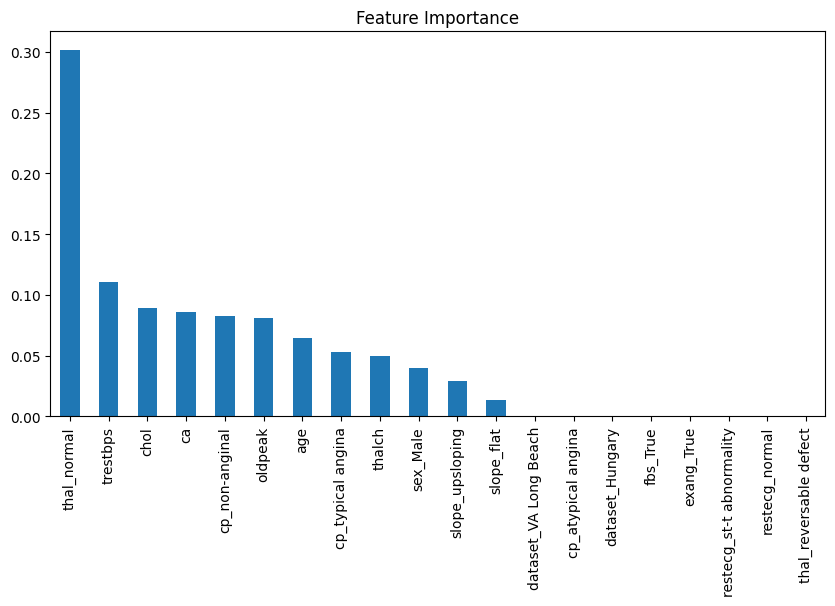

In [16]:
feature_importance = pd.Series(clf.feature_importances_, index=df.drop("num", axis=1).columns)

feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [17]:
# Prediction
y_pred = clf.predict(X_test)

In [18]:
# Performance Metrics (Classification)
print("=== Classification Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Classification Results ===
Accuracy: 0.8

Confusion Matrix:
 [[28  7]
 [ 5 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.80      0.82        35
           1       0.74      0.80      0.77        25

    accuracy                           0.80        60
   macro avg       0.79      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



In [19]:
print("\nTraining Accuracy:", clf.score(X_train, y_train))
print("Testing Accuracy:", clf.score(X_test, y_test))


Training Accuracy: 0.9414225941422594
Testing Accuracy: 0.8


PART B: DECISION TREE REGRESSION

In [20]:
# Train Regressor
reg = DecisionTreeRegressor()
reg.fit(X_train, y_train)

DecisionTreeRegressor()

In [21]:
# Prediction
y_pred_reg = reg.predict(X_test)

In [22]:
# Performance Metrics (Regression)
print("=== Regression Results ===")

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_reg))

print("R2 Score:", r2_score(y_test, y_pred_reg))

=== Regression Results ===
Mean Squared Error: 0.2
R2 Score: 0.17714285714285705


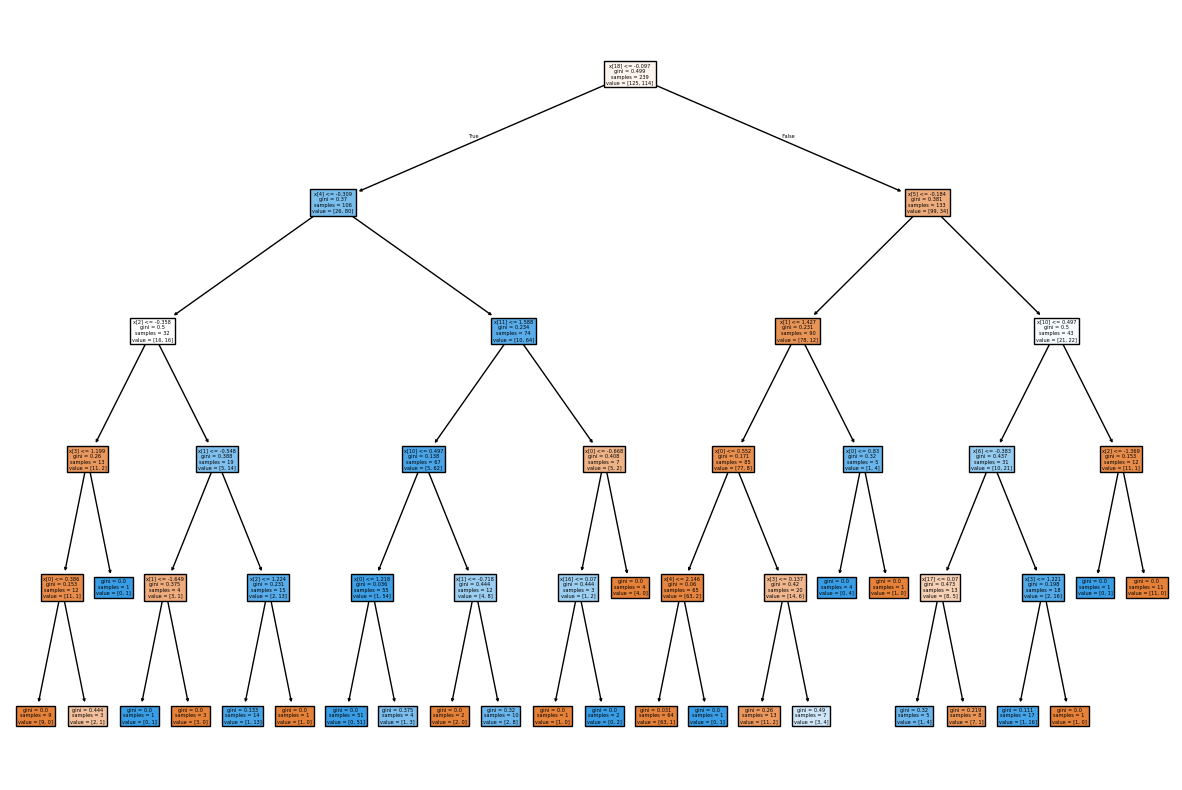

In [23]:
# Visualize Decision Tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
tree.plot_tree(clf, filled=True)
plt.show()

Conclusion:
The Decision Tree model was successfully implemented on the Heart Disease dataset.
The model performed classification and regression tasks effectively.
Performance metrics such as accuracy, confusion matrix, MSE, and R2 score were evaluated.
Feature importance analysis provided insights into key contributing factors.